<a href="https://colab.research.google.com/github/haftamugebremaryam16/Machine-Learning/blob/main/Linear_Regression_using_Multiple_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
housing = fetch_california_housing()
X_train=np.array(housing.data)
y_train=np.array(housing.target)

In [5]:
feature_names=['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']

Text(0, 0.5, "Price (1000's)")

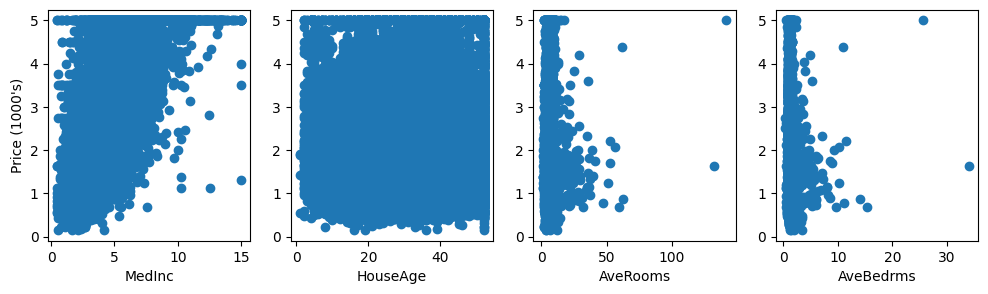

In [7]:
fig,ax=plt.subplots(1,4,figsize=(12,3))
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train[:])
    ax[i].set_xlabel(feature_names[i])
ax[0].set_ylabel("Price (1000's)")


Text(0, 0.5, "Price (1000's)")

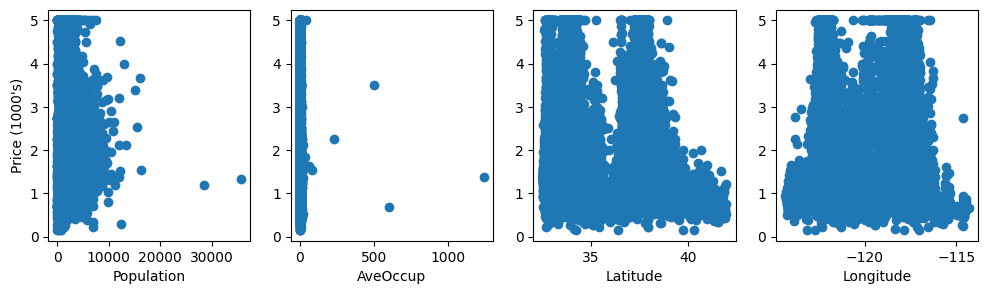

In [6]:

fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4, 8):
    ax[i-4].scatter(X_train[:, i], y_train)
    ax[i-4].set_xlabel(feature_names[i])

ax[0].set_ylabel("Price (1000's)")

$$
{J(w,b)}=\frac{1}{2m}\sum_{i=1}^m\left(f_{w,b}^{(i)}-y^{(i)}\right)^2
$$

In [8]:
def compute_cost(x,y,w,b):
  cost_total=0
  m=x.shape[0]
  f_x=np.dot(x,w)+b
  cost_total=np.sum((f_x-y)**2)
  cost_total/=2*m
  return cost_total

$$
\frac{\partial J(w,b)}{\partial w_j}=\frac {1}{m} \sum_{i=1}^{m}(f_{w,b}^{(i)}-y^{(i)})x_j^{(i)}
$$
$$
\frac{\partial J(w,b)}{\partial b}=\frac {1}{m} \sum_{i=1}^{m}(f_{w,b}^{(i)}-y^{(i)})
$$


In [19]:
def compute_gradientdescent(x,y,w,b):
  m=x.shape[0]

  f_x=np.dot(x,w)+b
  err=f_x-y

  j_w=np.dot(x.T,err)
  j_b=np.sum(err)
  return j_w/m,j_b/m


$$
{w}={w}-\alpha \frac{\partial J(w,b)}{\partial {w}}
$$
$$
{b}={b}-\alpha\frac{\partial J(w,b)}{\partial b}
$$

In [23]:
def gradientdescent(x,y,w,b,alpha,num_iter):
  cost_history=[]
  for i in range(num_iter):
    j_w,j_b=compute_gradientdescent(x,y,w,b)
    if i<100000:
      cost_history.append(compute_cost(x,y,w,b))
    w=w-alpha*j_w
    b=b-alpha*j_b
  return w,b,cost_history

In [24]:
def z_score(x):
  mu=np.mean(x,axis=0)
  sigma=np.std(x,axis=0)
  return (x-mu)/sigma,mu,sigma

In [25]:
X_norm,mu,sigma=z_score(X_train)

In [26]:

w=np.zeros(X_train.shape[1])
b=0
alpha=0.03
num_iter=1000
w,b,cost_history=gradientdescent(X_norm,y_train,w,b,alpha,num_iter)

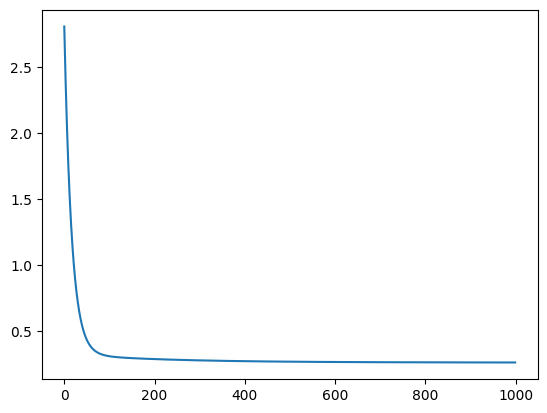

In [27]:
plt.plot(cost_history)
plt.show()

In [30]:
y_pred=np.dot(X_norm,w)+b
y_mean=np.mean(y_train)
ss_re=np.sum((y_train-y_pred)**2)
ss_tot=np.sum((y_train-y_mean)**2)
r2=1-(ss_re/ss_tot)
print(r2)

0.6049675321720218


In [31]:
print("Final Cost:", cost_history[-1])
print("R² Score:", r2)

Final Cost: 0.26300609741800746
R² Score: 0.6049675321720218
